# Practice quiz: Neural network model

---

# Quiz: Neural Network Fundamentals

## Question 1: Neural Network Activation Notation

For a neural network, what is the expression for calculating the activation of the **third neuron in layer 2**? Note, this is different from the question that you saw in the lecture video.

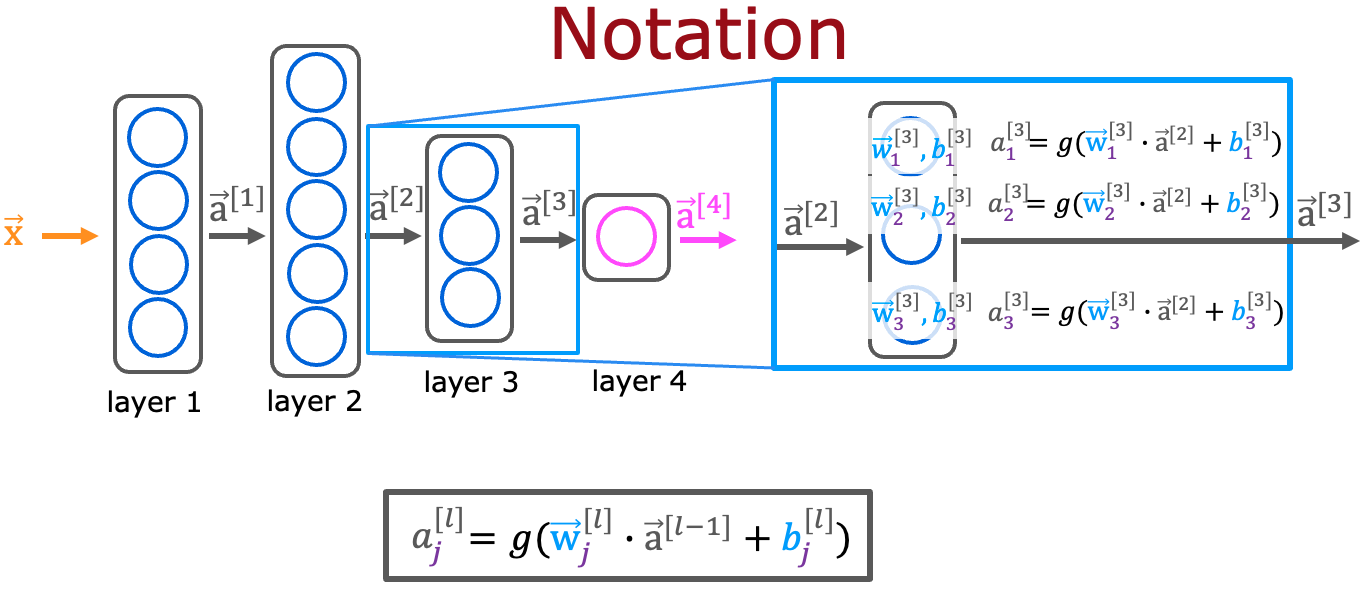

### Options:

- **Option A:** $a_3^{[2]} = g(\vec{w}_3^{[2]} \cdot \vec{a}^{[1]} + b_3^{[2]})$
- **Option B:** $a_3^{[2]} = g(\vec{w}_3^{[2]} \cdot \vec{a}^{[2]} + b_3^{[2]})$
- **Option C:** $a_3^{[2]} = g(\vec{w}_3^{[2]} \cdot \vec{a}^{[3]} + b_3^{[2]})$
- **Option D:** $a_3^{[2]} = g(\vec{w}_3^{[2]} \cdot \vec{a}^{[2]} + b_3^{[2]})$ (Note: This appears identical to Option B in the original question)

---

## Correct Answer: **Option A**

$a_3^{[2]} = g(\vec{w}_3^{[2]} \cdot \vec{a}^{[1]} + b_3^{[2]})$

---

## Detailed Explanation

### Understanding the Notation

Before diving into why Option A is correct, let's decode what each symbol means:

| **Symbol** | **Meaning** | **Example Interpretation** |
|------------|-------------|----------------------------|
| $a_3^{[2]}$ | Activation of the **3rd neuron** in **layer 2** | The output value of neuron #3 in the second hidden layer |
| $\vec{w}_3^{[2]}$ | Weight vector for the **3rd neuron** in **layer 2** | All weights connecting previous layer's neurons to this specific neuron |
| $\vec{a}^{[1]}$ | Activation **vector** from **layer 1** (previous layer) | The output of all neurons in the first hidden layer |
| $b_3^{[2]}$ | Bias term for the **3rd neuron** in **layer 2** | A learned offset for this specific neuron |
| $g(\cdot)$ | Activation function (sigmoid in this course) | Introduces non-linearity to the network |
| $\cdot$ | Dot product | Sum of element-wise multiplication |

### Why Option A is Correct

The fundamental rule for neural network forward propagation is:

> **Each neuron receives input from the PREVIOUS layer's activations, not from its own layer or future layers.**

For the third neuron in layer 2:
- The neuron belongs to **layer 2** (indicated by $[2]$)
- It is the **third neuron** in that layer (indicated by $_3$)
- Therefore, it must receive input from **layer 1** ($\vec{a}^{[1]}$)
- It uses its **own parameters** ($\vec{w}_3^{[2]}$ and $b_3^{[2]}$)

This follows the general formula:

$$a_j^{[l]} = g(\vec{w}_j^{[l]} \cdot \vec{a}^{[l-1]} + b_j^{[l]})$$

Where:
- $l$ = current layer (2 in this case)
- $l-1$ = previous layer (1 in this case)
- $j$ = neuron index in current layer (3 in this case)

### Visual Representation



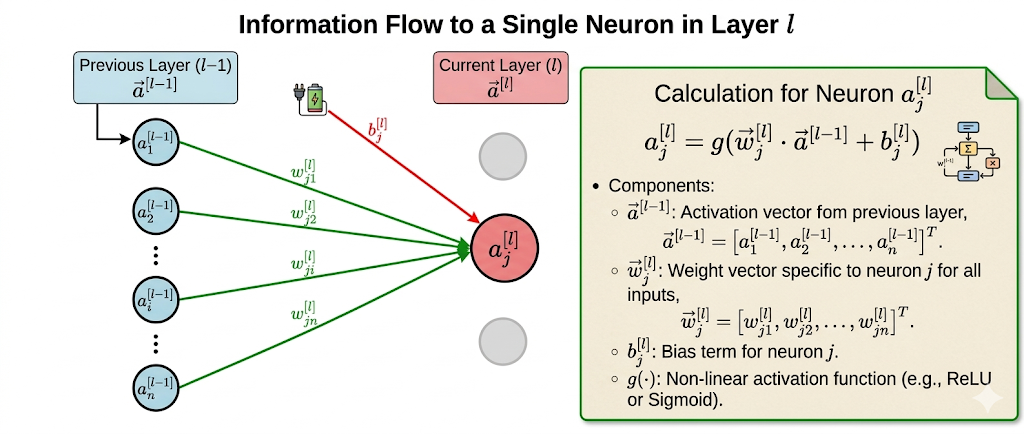


## Analysis of Incorrect Options

### Option B: $a_3^{[2]} = g(\vec{w}_3^{[2]} \cdot \vec{a}^{[2]} + b_3^{[2]})$

**Why this is incorrect:** This option uses $\vec{a}^{[2]}$ (the activations of layer 2) as input to a neuron in layer 2. This would create a **circular dependency** where a neuron tries to use its own output (or its neighbors' outputs from the same layer) as input. In feedforward neural networks, information flows strictly forward—neurons in a layer cannot receive input from the same layer because those activations haven't been computed yet when processing the current layer.

**Analogy:** This would be like trying to read a book while simultaneously writing it—you need the previous chapters (previous layer) to understand what comes next, not the chapter you're currently writing.

---

### Option C: $a_3^{[2]} = g(\vec{w}_3^{[2]} \cdot \vec{a}^{[3]} + b_3^{[2]})$

**Why this is incorrect:** This option uses $\vec{a}^{[3]}$ (activations from layer 3, a **future** layer) as input. This violates the fundamental principle of forward propagation—information cannot flow from future layers to earlier layers. Layer 3 hasn't been computed yet when we're processing layer 2, so it's impossible for layer 2 to receive input from layer 3.

**Analogy:** This would be like trying to know the ending of a movie before watching the middle—the future depends on the present, not the other way around.

---

### Option D: (Identical to Option B)

The same reasoning applies—this option also incorrectly uses $\vec{a}^{[2]}$ as input.

---

## Common Misconceptions

| **Misconception** | **Reality** |
|-------------------|-------------|
| "The superscript indicates which layer's parameters to use, so input should match" | Parameters use current layer's superscript ($[2]$), but input always comes from previous layer ($[1]$) |
| "All notations with $[2]$ should be consistent" | The layer index for parameters and input are deliberately different—they serve different purposes |
| "The neuron number determines the input source" | The neuron number only identifies which set of parameters to use, not where the input comes from |

---

## Real-World Example: Handwriting Recognition

Consider a neural network designed to recognize handwritten digits:

- **Layer 1 (Input layer, $a^{[0]}$):** Raw pixel values of a scanned digit (e.g., 28×28 = 784 pixels)
- **Layer 1 → Layer 2:** The first hidden layer ($a^{[1]}$) detects simple patterns like edges and curves
- **Layer 2 → Layer 3:** The second hidden layer ($a^{[2]}$) combines these edges to detect more complex features like loops and lines
- **Layer 3 → Output:** The final layer ($a^{[3]}$) combines these features to recognize specific digits

When computing the activation of the third neuron in layer 2 ($a_3^{[2]}$), it MUST use the outputs from layer 1 ($a^{[1]}$) because:
- Layer 1 has already detected the basic edges
- The third neuron in layer 2 is trying to detect a specific pattern (e.g., a vertical line)
- It needs the edge information from layer 1 to determine if a vertical line is present
- It cannot use information from its own layer (layer 2) because those neurons are also trying to detect patterns simultaneously
- It certainly cannot use information from future layers (layer 3) that haven't been computed yet

---

## Key Takeaway

> **The activation of a neuron in layer l always depends on the activations from layer l-1, using its own parameters (weights and bias) from layer l.**

This forward-only flow of information is what makes neural networks "feedforward" networks and enables them to learn hierarchical representations of data.

---



## Question 2: Handwritten Digit Recognition Output Interpretation

For the handwriting recognition task discussed in lecture, what is the output $a_1^{[3]}$?

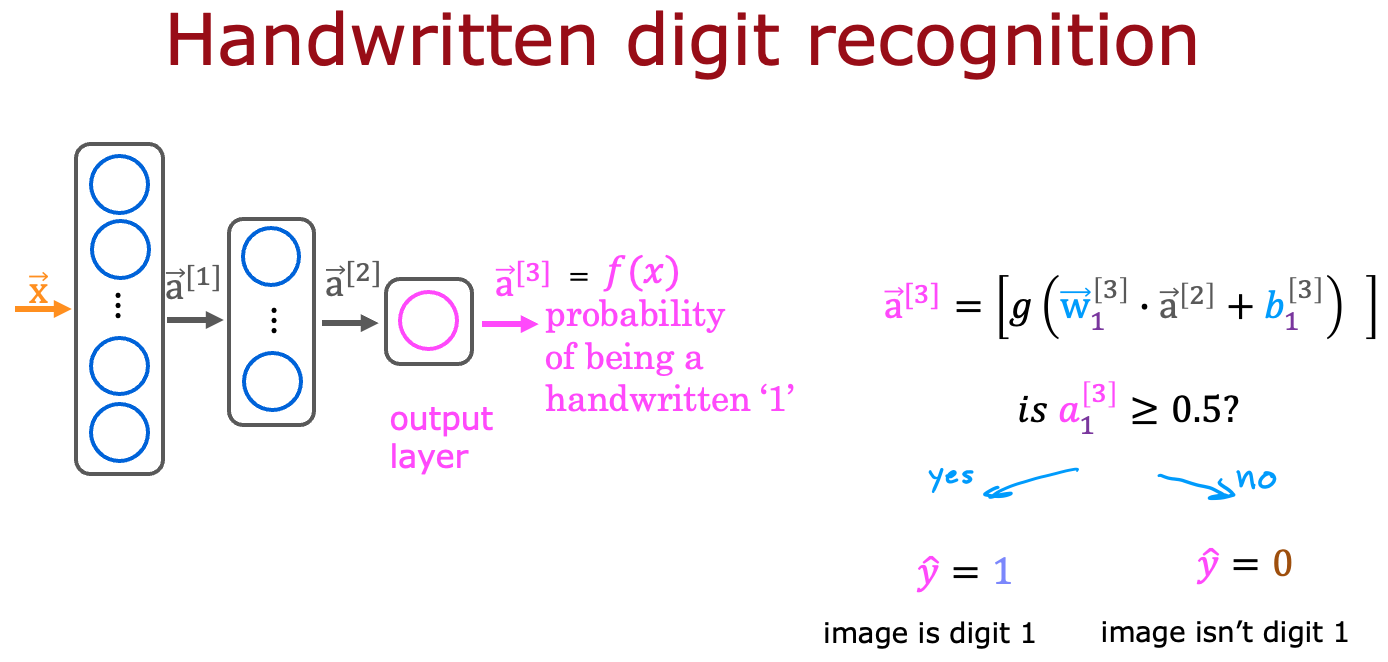

### Options:

- **Option A:** The estimated probability that the input image is of a number 1, a number that ranges from 0 to 1.
- **Option B:** A number that is either exactly 0 or 1, comprising the network's prediction.
- **Option C:** A vector of several numbers that take values between 0 and 1.
- **Option D:** A vector of several numbers, each of which is either exactly 0 or 1.

---

## Correct Answer: **Option A**

The estimated probability that the input image is of a number 1, a number that ranges from 0 to 1.

---

## Detailed Explanation

### Understanding the Output Layer Configuration

In the handwritten digit recognition example from the lecture, the neural network is designed for **binary classification**—distinguishing between just two classes: digit '0' and digit '1'.

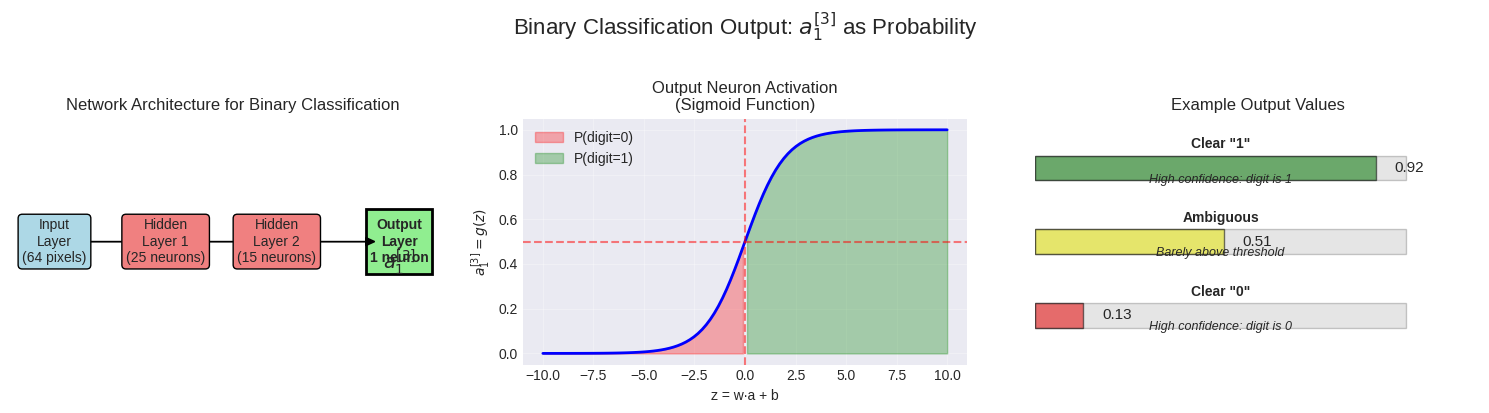

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# Create a visualization of binary classification output
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Neural network architecture
ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis('off')

# Input layer (simplified)
ax.text(1, 3, 'Input\nLayer\n(64 pixels)', ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

# Hidden layers
ax.text(3.5, 3, 'Hidden\nLayer 1\n(25 neurons)', ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))
ax.text(6, 3, 'Hidden\nLayer 2\n(15 neurons)', ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="lightcoral"))

# Output layer - SINGLE neuron
output_box = plt.Rectangle((8, 2.2), 1.5, 1.6, facecolor='lightgreen', edgecolor='black', linewidth=2)
ax.add_patch(output_box)
ax.text(8.75, 3, 'Output\nLayer\n1 neuron', ha='center', va='center', fontweight='bold')
ax.text(8.75, 2.5, '$a_1^{[3]}$', ha='center', va='center', fontsize=14, fontweight='bold')

# Arrows
ax.arrow(1.8, 3, 1.2, 0, head_width=0.2, head_length=0.2, fc='black', ec='black')
ax.arrow(4.3, 3, 1.2, 0, head_width=0.2, head_length=0.2, fc='black', ec='black')
ax.arrow(6.8, 3, 1.2, 0, head_width=0.2, head_length=0.2, fc='black', ec='black')

ax.set_title('Network Architecture for Binary Classification', fontsize=12)

# Plot 2: Sigmoid output function
z = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-z))

axes[1].plot(z, sigmoid, 'b-', linewidth=2)
axes[1].axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
axes[1].axvline(x=0, color='r', linestyle='--', alpha=0.5)
axes[1].fill_between(z, 0, sigmoid, where=(z<=0), alpha=0.3, color='red', label='P(digit=0)')
axes[1].fill_between(z, 0, sigmoid, where=(z>=0), alpha=0.3, color='green', label='P(digit=1)')
axes[1].set_xlabel('z = w·a + b')
axes[1].set_ylabel('$a_1^{[3]} = g(z)$')
axes[1].set_title('Output Neuron Activation\n(Sigmoid Function)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()
axes[1].set_ylim(-0.05, 1.05)

# Plot 3: Output interpretation
ax3 = axes[2]
ax3.axis('off')

examples = [
    ('Clear "1"', 0.92, 'green', 'High confidence: digit is 1'),
    ('Ambiguous', 0.51, 'yellow', 'Barely above threshold'),
    ('Clear "0"', 0.13, 'red', 'High confidence: digit is 0'),
]

y_pos = [4, 2.5, 1]
for i, (label, prob, color, desc) in enumerate(examples):
    # Probability bar
    ax3.barh(y_pos[i], prob, height=0.5, color=color, alpha=0.6, edgecolor='black')
    ax3.barh(y_pos[i], 1, height=0.5, color='gray', alpha=0.2, edgecolor='black')
    ax3.text(prob + 0.05, y_pos[i], f'{prob:.2f}', va='center', fontsize=11)
    ax3.text(0.5, y_pos[i] + 0.4, label, ha='center', fontsize=10, fontweight='bold')
    ax3.text(0.5, y_pos[i] - 0.3, desc, ha='center', fontsize=9, style='italic')

ax3.set_xlim(0, 1.2)
ax3.set_ylim(0, 5)
ax3.set_xlabel('Probability')
ax3.set_title('Example Output Values', fontsize=12)

plt.suptitle('Binary Classification Output: $a_1^{[3]}$ as Probability', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()


### Why Option A is Correct

In the lecture's handwritten digit recognition example:

1. **The output layer has a SINGLE neuron** ($a_1^{[3]}$), not a vector of neurons
2. **This single neuron uses the sigmoid activation function**, which outputs values between 0 and 1
3. **The output represents a probability**—specifically, $P(y=1 | x)$, the probability that the input image is a '1' given the input features
4. **The range is continuous from 0 to 1**, not just discrete 0 or 1 values

The lecture explicitly states that the network computes "the chance of this being 1 versus 0" and that you can "optionally take a3, subscript 1, and threshold it at 0.5 to come up with a binary classification label."

---

## Comparison of All Options

| **Option** | **Description** | **Correct?** | **Reason** |
|------------|-----------------|--------------|------------|
| **A** | Estimated probability (0 to 1) | ✅ **Correct** | Matches sigmoid output interpretation |
| **B** | Exactly 0 or 1 (binary) | ❌ Incorrect | This is the thresholded prediction ($\hat{y}$), not $a_1^{[3]}$ |
| **C** | Vector of numbers (0 to 1) | ❌ Incorrect | Output is a scalar, not a vector |
| **D** | Vector of binary values | ❌ Incorrect | Both vector and binary aspects are wrong |

---

## The Distinction: Probability vs. Prediction

This question highlights a crucial distinction in neural network outputs:

### Raw Output ($a_1^{[3]}$)
- **What it is:** The raw activation of the output neuron
- **Range:** Continuous between 0 and 1
- **Interpretation:** Probability estimate
- **Usage:** Represents confidence/uncertainty

### Thresholded Prediction ($\hat{y}$)
- **What it is:** The final classification after applying a threshold
- **Range:** Discrete {0, 1}
- **Interpretation:** Hard classification
- **Usage:** When you need a definitive yes/no answer



<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:29: SyntaxWarning: invalid escape sequence '\h'
<>:22: SyntaxWarning: invalid escape sequence '\h'
<>:29: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_266/1771025822.py:22: SyntaxWarning: invalid escape sequence '\h'
  ax2.step(probabilities, predictions, 'r-', linewidth=2, where='post', label='$\hat{y}$ (prediction)')
/tmp/ipykernel_266/1771025822.py:29: SyntaxWarning: invalid escape sequence '\h'
  ax2.set_title('Thresholded Output: Binary Prediction\n$\hat{y} \in \{0,1\}$')


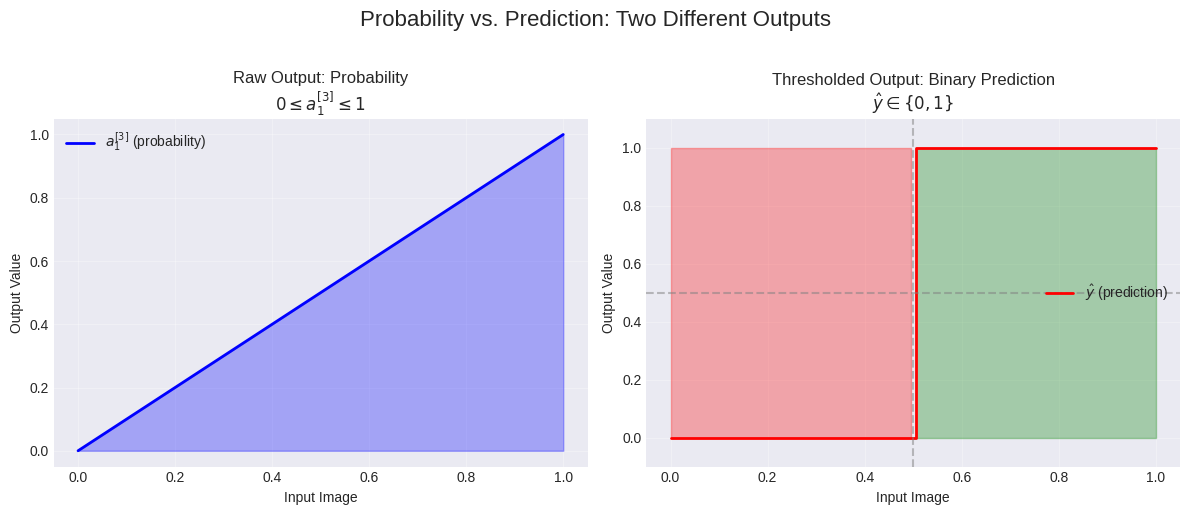

PROBABILITY VS PREDICTION: KEY DIFFERENCES

Raw probability (a₁³) for an ambiguous image: 0.51
Thresholded prediction (ŷ): 1 (since 0.51 ≥ 0.5)

Raw probability (a₁³) for a clear '0': 0.13
Thresholded prediction (ŷ): 0 (since 0.13 < 0.5)

The network first computes the probability, THEN optionally thresholds it.
The question asks for a₁³, which is the probability, NOT the thresholded value.


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Create visualization of probability vs prediction
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Sample data
probabilities = np.linspace(0, 1, 100)
threshold = 0.5
predictions = (probabilities >= threshold).astype(int)

# Plot 1: Probabilities
ax1.plot(probabilities, probabilities, 'b-', linewidth=2, label='$a_1^{[3]}$ (probability)')
ax1.fill_between(probabilities, 0, probabilities, alpha=0.3, color='blue')
ax1.set_xlabel('Input Image')
ax1.set_ylabel('Output Value')
ax1.set_title('Raw Output: Probability\n$0 \\leq a_1^{[3]} \\leq 1$')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Binary predictions
ax2.step(probabilities, predictions, 'r-', linewidth=2, where='post', label='$\hat{y}$ (prediction)')
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=threshold, color='gray', linestyle='--', alpha=0.5)
ax2.fill_between(probabilities, 0, 1, where=(probabilities>=threshold), alpha=0.3, color='green')
ax2.fill_between(probabilities, 0, 1, where=(probabilities<threshold), alpha=0.3, color='red')
ax2.set_xlabel('Input Image')
ax2.set_ylabel('Output Value')
ax2.set_title('Thresholded Output: Binary Prediction\n$\hat{y} \in \{0,1\}$')
ax2.grid(True, alpha=0.3)
ax2.legend()
ax2.set_ylim(-0.1, 1.1)

plt.suptitle('Probability vs. Prediction: Two Different Outputs', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Print explanation
print("=" * 60)
print("PROBABILITY VS PREDICTION: KEY DIFFERENCES")
print("=" * 60)
print(f"\nRaw probability (a₁³) for an ambiguous image: 0.51")
print(f"Thresholded prediction (ŷ): 1 (since 0.51 ≥ 0.5)")
print(f"\nRaw probability (a₁³) for a clear '0': 0.13")
print(f"Thresholded prediction (ŷ): 0 (since 0.13 < 0.5)")
print("\nThe network first computes the probability, THEN optionally thresholds it.")
print("The question asks for a₁³, which is the probability, NOT the thresholded value.")
print("=" * 60)



## Analysis of Incorrect Options

### Option B: "A number that is either exactly 0 or 1"

**Why this is incorrect:** This describes $\hat{y}$ (the final prediction after thresholding), not $a_1^{[3]}$. The lecture explicitly shows thresholding as an **optional** step after computing $a_1^{[3]}$:

> "Once the neural network has computed A2, there's one final optional step that you can choose to implement or not... if it's greater than 0.5, you can predict y-hat equals one, and if it's less than 0.5, then predict y-hat equals zero."

The thresholding happens **after** obtaining $a_1^{[3]}$, so $a_1^{[3]}$ itself is the pre-threshold probability.

---

### Option C: "A vector of several numbers that take values between 0 and 1"

**Why this is incorrect:** In this specific binary classification example, the output layer has only **one neuron**. The notation $a_1^{[3]}$ confirms this—the subscript "1" indicates this is the first (and only) neuron in layer 3. A vector output would be denoted as $\vec{a}^{[3]}$ without a subscript, or with multiple subscripts like $a_1^{[3]}, a_2^{[3]}, ...$ for multiple output neurons.

For multi-class classification (e.g., recognizing all digits 0-9), the output layer would indeed be a vector, but this specific question refers to the binary classification example from the lecture.

---

### Option D: "A vector of several numbers, each of which is either exactly 0 or 1"

**Why this is incorrect:** This option combines both errors from options B and C:
- It suggests a **vector** output (incorrect for binary classification)
- It suggests **binary values** (incorrect for raw activations)

This might describe a multi-class classification problem with one-hot encoded targets, but it does NOT describe $a_1^{[3]}$ in the lecture's handwritten digit recognition example.

---

## Real-World Examples

### Example 1: Medical Diagnosis
- **Network output ($a_1^{[3]}$):** 0.87 probability that a patient has a disease
- **Doctor's interpretation:** "There's an 87% chance this patient has the disease"
- **Thresholded decision:** If treatment threshold is 0.7, doctor treats; if 0.9, they might run more tests

### Example 2: Email Spam Detection
- **Network output ($a_1^{[3]}$):** 0.23 probability that an email is spam
- **Email client display:** Could show "23% spam probability" in the interface
- **Filtering decision:** If threshold is 0.5, this email goes to inbox; if threshold is 0.2, it goes to spam

### Example 3: Credit Card Fraud Detection
- **Network output ($a_1^{[3]}$):** 0.94 probability that a transaction is fraudulent
- **Bank's response:** High probability triggers immediate block
- **Risk assessment:** The probability itself is valuable for risk scoring, not just the binary decision

---

## Summary Table: Neural Network Output Types

| **Task Type** | **Output Layer** | **Output Value** | **Interpretation** | **Example** |
|---------------|------------------|------------------|-------------------|-------------|
| **Binary Classification** | 1 neuron | Single probability (0 to 1) | $P(\text{class 1} \| x)$ | Digit is '1' vs '0' |
| **Multi-class Classification** | C neurons (C = # classes) | Probability vector (sums to 1) | $P(\text{class i} \| x)$ for each class | Digit is 0,1,2,...,9 |
| **Regression** | 1+ neurons | Continuous values (any real number) | Predicted target value | House price prediction |

---

## Key Takeaway

> **In binary classification, $a_1^{[3]}$ represents a probability—a continuous value between 0 and 1. The binary prediction $\hat{y}$ is obtained by optionally thresholding this probability, but they are distinct quantities.**

Always distinguish between:
- **What the network computes** (probabilities/activations)
- **What decision we make** (thresholded predictions)

---

## Final Revision Notes

### Quick Reference Card

| **Concept** | **Formula/Expression** | **Key Insight** |
|-------------|------------------------|-----------------|
| Neuron activation | $a_j^{[l]} = g(\vec{w}_j^{[l]} \cdot \vec{a}^{[l-1]} + b_j^{[l]})$ | Input comes from previous layer ($l-1$) |
| Layer index meaning | Superscript $[l]$ indicates which layer the neuron belongs to | Parameters also use this layer index |
| Neuron index meaning | Subscript $j$ identifies which neuron in the layer | Each neuron has its own parameters |
| Binary classification output | $a_1^{[3]} \in [0,1]$ | Probability estimate from sigmoid |
| Binary prediction | $\hat{y} = \mathbb{1}(a_1^{[3]} > 0.5)$ | Thresholded decision (optional) |

### Common Pitfalls to Avoid

1. ❌ **Mixing up layer indices** in input references
2. ❌ **Confusing probability outputs** with thresholded predictions
3. ❌ **Assuming vector outputs** for binary classification tasks
4. ❌ **Misreading notation**—always check superscripts and subscripts carefully

---

*"In neural networks, precision in notation leads to precision in understanding. Every superscript and subscript tells you exactly where information comes from and where it's going."*